# Customer Segmentation with Clustering

## Introduction

Understanding different types of customers is important for improving marketing strategies, customer satisfaction, and customer retention. When businesses know who their customers are and how they behave, they can make better decisions about pricing, communication, and where to focus their resources. Customer segmentation is one way to do this, as it helps identify groups of customers who share similar characteristics.

Customer segmentation can be based on many different types of information, such as demographics (for example age), geography (such as country or region), and behavioural patterns (such as how often someone purchases). In this mini-project, the focus is on clustering customers based on purchasing behaviour and customer value. Although this project is presented in a retail setting, the same methods can be applied to many other sectors, such as banking, technology, travel, and healthcare, where organisations also need to understand different customer or user groups.

## Business context

The dataset used in this project is an e-commerce dataset from a real-world organisation. It includes customer orders from 47 countries across five continents (Oceania, North America, Europe, Africa, and Asia). The dataset contains 951,668 rows, where each row represents a product ordered by a customer. It includes both customer information (for example location and loyalty membership) and order information (for example order dates, delivery dates, unit cost, revenue, and profit), covering orders between 1 January 2012 and 30 December 2016.

Since the dataset is at transaction level, feature engineering is needed to create meaningful customer-level variables that can be used for clustering. In this project, the customer ID is used to aggregate the data and build a dataset where each row represents a unique customer.

## Key features

To segment customers in a way that is relevant for marketing and customer strategy, the following features are created and used:

- Frequency: how often a customer purchases

- Recency: time since the last purchase

- Customer lifetime value (CLV): the total value a customer has contributed

- Average unit cost: how much a customer spends on average

- Customer age

These features help describe differences between customers in terms of activity, value, and purchasing behaviour.

## Project approach

This notebook follows a full customer segmentation workflow. First, the data is explored and cleaned, and the customer-level features are created. Next, clustering is performed using K-means, and different methods are used to determine the optimal number of clusters. These methods include the elbow method, silhouette scores, and hierarchical clustering with a dendrogram. Finally, dimensionality reduction methods such as PCA and t-SNE are used to support visualisation and interpretation of the clusters.

The aim of this project is to identify meaningful customer groups and show how clustering methods can be used to support customer segmentation in a clear and interpretable way.

# Import libraries and dataset

In [1]:
# import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import the dataset
customer = pd.read_csv('https://github.com/FourthRevGitHub/CAM_DS_Public-Data-Sets/raw/main/Course%201/Week%206/CUSTOMERS_CLEAN.zip')

# View dataframe
customer.head()

,Quantity,City,Continent,Postal_Code,State_Province,Order_Date,Delivery_Date,Total Revenue,Unit Cost,Discount,OrderTypeLabel,CustomerCountryLabel,Customer_BirthDate,Customer_Group,Customer_Type,Order ID,Profit,Days to Delivery,Loyalty Num,Customer ID
0,3,Leinster,Oceania,6437,Western Australia,01JAN2012,07JAN2012,$28.50,$9.10,.,Internet Sale,Australia,08MAY1978,Internet/Catalog Customers,Internet/Catalog Customers,1230000033,$1.20,6,99,8818
1,2,Berowra,Oceania,2081,New South Wales,01JAN2012,04JAN2012,$113.40,$56.90,.,Internet Sale,Australia,13DEC1978,Orion Club Gold members,Orion Club Gold members high activity,1230000204,($0.40),3,99,47793
2,2,Berowra,Oceania,2081,New South Wales,01JAN2012,04JAN2012,$41.00,$18.50,.,Internet Sale,Australia,13DEC1978,Orion Club Gold members,Orion Club Gold members high activity,1230000204,$4.00,3,99,47793
3,1,Northbridge,Oceania,2063,New South Wales,01JAN2012,03JAN2012,$35.20,$29.60,.,Internet Sale,Australia,22JUN1997,Orion Club Gold members,Orion Club Gold members high activity,1230000268,$5.60,2,0,71727
4,1,Montréal,North America,NaN,Quebec,01JAN2012,04JAN2012,$24.70,$23.60,.,Internet Sale,Canada,28JAN1978,Orion Club Gold members,Orion Club Gold members medium activity,1230000487,$1.10,3,99,74503


The libraries and dataset were imported. An overview of the first 5 rows is shown with the different variables.

# Data exploration and cleaning

In [2]:
# View length of dataframe
print(customer.shape)

(951669, 20)


The dataset has 951669 rows, which are the products ordered by the customers.

In [3]:
# Check for missing values
customer.isnull().sum()

,0
Quantity,0
City,135
Continent,0
Postal_Code,3716
State_Province,117192
Order_Date,0
Delivery_Date,0
Total Revenue,0
Unit Cost,0
Discount,0


In [4]:
# Calculate the missing percentage of each column with missing values
# List of columns to loop
columns_missing_list = ['City', 'Postal_Code', 'State_Province']

# Loop through the columns and calculate the missing percentage
for column in columns_missing_list:
    missing_count = customer[column].isnull().sum()
    total_count = len(customer)
    missing_percentage = (missing_count / total_count) * 100
    print(f"The percentage of missing values for {column} is: {missing_percentage:.2f}%")

The percentage of missing values for City is: 0.01%
The percentage of missing values for Postal_Code is: 0.39%
The percentage of missing values for State_Province is: 12.31%


The missing values are: 135 for 'City', 3716 for 'Postal_Code', and 117192 for 'State_Province'. The other features do not have missing values. None of the features contain more than 50% missing values. Therefore, I will keep the features in the dataset. A domain expert could advise on whether it would be helpful to remove any column that contains missing values or to change the missing values to the median (or in this case the most common city, postal code or state/province in that country). For now, I will leave them as it is and only deal with missing values for the variables needed for analyis.

In [5]:
# Check dataset for duplicate rows
duplicates = customer.duplicated()
print(duplicates.sum())

# Make a list of duplicates indexes
duplicates_index = duplicates[duplicates].index.tolist()
print(duplicates_index)

21
[25809, 59723, 60475, 71116, 85386, 88399, 144437, 245412, 280487, 289173, 303247, 337841, 374959, 474803, 597962, 640384, 660458, 684595, 720820, 745846, 754744]


There are 21 duplicate rows in the dataset.

In [6]:
# Clean the dataset
# Drop duplicate rows
customer_clean = customer.drop_duplicates()

# View output
customer_clean.duplicated().sum()

np.int64(0)

There are no duplicated rows in the new dataset.

In [7]:
# View head
customer_clean.head()

,Quantity,City,Continent,Postal_Code,State_Province,Order_Date,Delivery_Date,Total Revenue,Unit Cost,Discount,OrderTypeLabel,CustomerCountryLabel,Customer_BirthDate,Customer_Group,Customer_Type,Order ID,Profit,Days to Delivery,Loyalty Num,Customer ID
0,3,Leinster,Oceania,6437,Western Australia,01JAN2012,07JAN2012,$28.50,$9.10,.,Internet Sale,Australia,08MAY1978,Internet/Catalog Customers,Internet/Catalog Customers,1230000033,$1.20,6,99,8818
1,2,Berowra,Oceania,2081,New South Wales,01JAN2012,04JAN2012,$113.40,$56.90,.,Internet Sale,Australia,13DEC1978,Orion Club Gold members,Orion Club Gold members high activity,1230000204,($0.40),3,99,47793
2,2,Berowra,Oceania,2081,New South Wales,01JAN2012,04JAN2012,$41.00,$18.50,.,Internet Sale,Australia,13DEC1978,Orion Club Gold members,Orion Club Gold members high activity,1230000204,$4.00,3,99,47793
3,1,Northbridge,Oceania,2063,New South Wales,01JAN2012,03JAN2012,$35.20,$29.60,.,Internet Sale,Australia,22JUN1997,Orion Club Gold members,Orion Club Gold members high activity,1230000268,$5.60,2,0,71727
4,1,Montréal,North America,NaN,Quebec,01JAN2012,04JAN2012,$24.70,$23.60,.,Internet Sale,Canada,28JAN1978,Orion Club Gold members,Orion Club Gold members medium activity,1230000487,$1.10,3,99,74503


In [8]:
# View shape
print(customer_clean.shape)

(951648, 20)


Without the duplicate rows, there are now 951648 rows.

To check for outliers, I will first use descriptive statistics.

In [9]:
# Describe the features of the dataset
customer_clean.describe()

,Quantity,Order ID,Days to Delivery,Loyalty Num,Customer ID
count,951648.000000,9.516480e+05,951648.000000,951648.000000,951648.000000
mean,1.678440,1.236943e+09,1.056116,66.533986,45440.675518
std,0.899921,4.273202e+06,2.065731,46.476828,27214.093293
min,1.000000,1.230000e+09,0.000000,0.000000,1.000000
25%,1.000000,1.233081e+09,0.000000,0.000000,22139.000000
50%,1.000000,1.236755e+09,0.000000,99.000000,44140.000000
75%,2.000000,1.240689e+09,1.000000,99.000000,70411.000000
max,10.000000,1.244338e+09,32.000000,99.000000,94254.000000


We can see that for Quantity and Days to Delivery, there will be many values which are more than 2 standard deviations above the mean.

In [10]:
# Check the data type for each variable
customer_clean.dtypes

,0
Quantity,int64
City,object
Continent,object
Postal_Code,object
State_Province,object
Order_Date,object
Delivery_Date,object
Total Revenue,object
Unit Cost,object
Discount,object


Quantity is an integer, which is correct. I will explore this feature with a histogram and a boxplot.

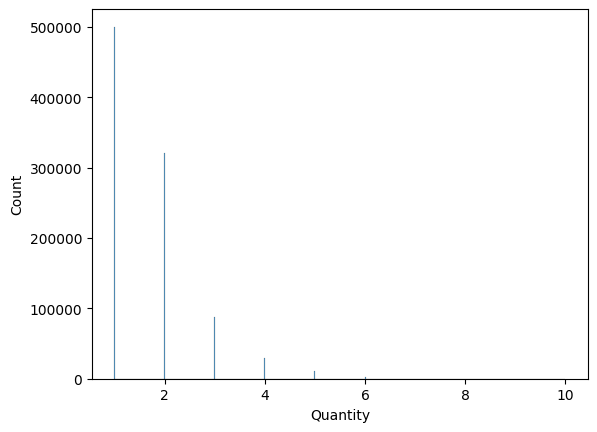

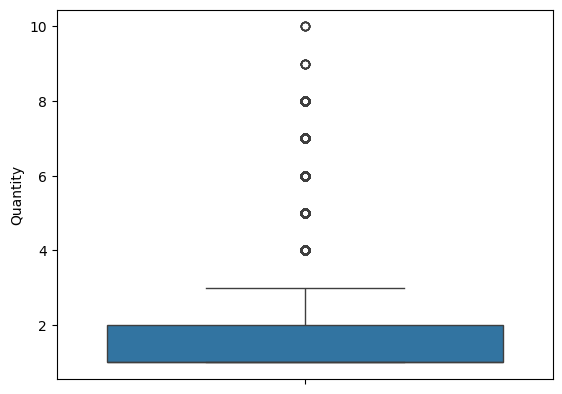

In [11]:
# Generate a histogram and boxplot for 'Quantity'
sns.histplot(customer_clean['Quantity'])
plt.show()
sns.boxplot(customer_clean['Quantity'])
plt.show()

The quantity varies from 1 to 10 products per order. Any oder with more 4 or more products, is shown as an outlier in the boxplot. I will also generate a bar plot for visualisation.

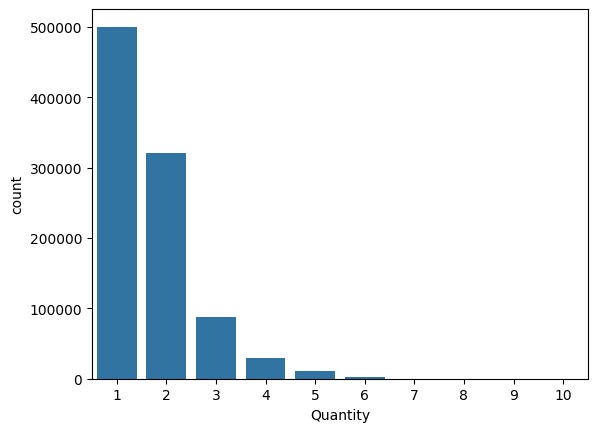

In [12]:
# Generate barplot for 'Quantity'
sns.countplot(x='Quantity', data=customer_clean)
plt.show()

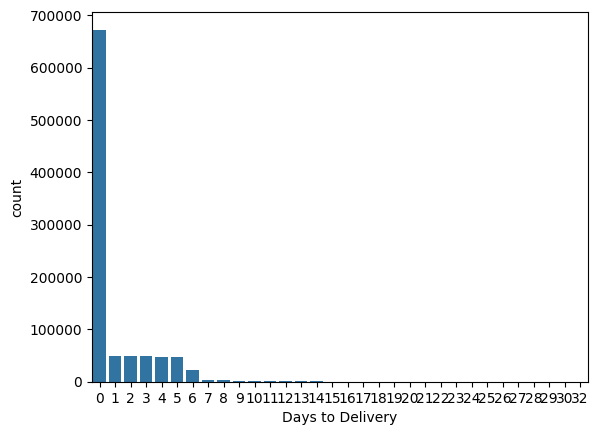

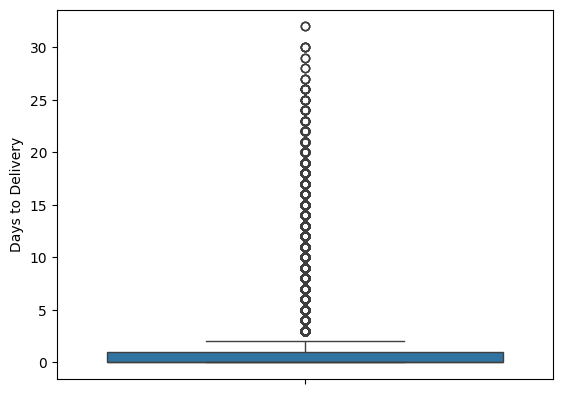

In [13]:
# Create a barchart and boxplot for 'Days to Delivery'
sns.countplot(x='Days to Delivery', data=customer_clean)
plt.show()
sns.boxplot(customer_clean['Days to Delivery'])
plt.show()

Days to delivery varies from 0 to 32 days, with any delivery taking 3 days or longer classified as outliers.

# Feature engineering

In [14]:
# Perform feature engineering
# Creat a new feature called 'Frequency'
customer_clean = customer_clean.copy()
customer_clean['Frequency'] = customer_clean.groupby('Customer ID')['Order ID'].transform('count')

# View output
customer_clean.head()

,Quantity,City,Continent,Postal_Code,State_Province,Order_Date,Delivery_Date,Total Revenue,Unit Cost,Discount,...,CustomerCountryLabel,Customer_BirthDate,Customer_Group,Customer_Type,Order ID,Profit,Days to Delivery,Loyalty Num,Customer ID,Frequency
0,3,Leinster,Oceania,6437,Western Australia,01JAN2012,07JAN2012,$28.50,$9.10,.,...,Australia,08MAY1978,Internet/Catalog Customers,Internet/Catalog Customers,1230000033,$1.20,6,99,8818,31
1,2,Berowra,Oceania,2081,New South Wales,01JAN2012,04JAN2012,$113.40,$56.90,.,...,Australia,13DEC1978,Orion Club Gold members,Orion Club Gold members high activity,1230000204,($0.40),3,99,47793,20
2,2,Berowra,Oceania,2081,New South Wales,01JAN2012,04JAN2012,$41.00,$18.50,.,...,Australia,13DEC1978,Orion Club Gold members,Orion Club Gold members high activity,1230000204,$4.00,3,99,47793,20
3,1,Northbridge,Oceania,2063,New South Wales,01JAN2012,03JAN2012,$35.20,$29.60,.,...,Australia,22JUN1997,Orion Club Gold members,Orion Club Gold members high activity,1230000268,$5.60,2,0,71727,20
4,1,Montréal,North America,NaN,Quebec,01JAN2012,04JAN2012,$24.70,$23.60,.,...,Canada,28JAN1978,Orion Club Gold members,Orion Club Gold members medium activity,1230000487,$1.10,3,99,74503,6


A new variable named 'Frequency' was added to the dataframe.

In [15]:
# Create new variable called 'Recency': the time since last order
customer_clean['Recency'] = (pd.to_datetime('today') - pd.to_datetime(customer_clean['Delivery_Date'], format= '%d%b%Y')).dt.days

# View output
customer_clean.head()

,Quantity,City,Continent,Postal_Code,State_Province,Order_Date,Delivery_Date,Total Revenue,Unit Cost,Discount,...,Customer_BirthDate,Customer_Group,Customer_Type,Order ID,Profit,Days to Delivery,Loyalty Num,Customer ID,Frequency,Recency
0,3,Leinster,Oceania,6437,Western Australia,01JAN2012,07JAN2012,$28.50,$9.10,.,...,08MAY1978,Internet/Catalog Customers,Internet/Catalog Customers,1230000033,$1.20,6,99,8818,31,5128
1,2,Berowra,Oceania,2081,New South Wales,01JAN2012,04JAN2012,$113.40,$56.90,.,...,13DEC1978,Orion Club Gold members,Orion Club Gold members high activity,1230000204,($0.40),3,99,47793,20,5131
2,2,Berowra,Oceania,2081,New South Wales,01JAN2012,04JAN2012,$41.00,$18.50,.,...,13DEC1978,Orion Club Gold members,Orion Club Gold members high activity,1230000204,$4.00,3,99,47793,20,5131
3,1,Northbridge,Oceania,2063,New South Wales,01JAN2012,03JAN2012,$35.20,$29.60,.,...,22JUN1997,Orion Club Gold members,Orion Club Gold members high activity,1230000268,$5.60,2,0,71727,20,5132
4,1,Montréal,North America,NaN,Quebec,01JAN2012,04JAN2012,$24.70,$23.60,.,...,28JAN1978,Orion Club Gold members,Orion Club Gold members medium activity,1230000487,$1.10,3,99,74503,6,5131


A new variable 'Recency' (number of days since the last order), was added to the dataframe.

In [16]:
# Create a new variable named CLV (customer lifetime value) which is the total revenue a customer contributes to the business over time, given the customer remains loyal to the business. This is the same as 'Total Revenue'.
# First, convert the currency to string
customer_clean['Total Revenue'] = customer_clean['Total Revenue'].astype(str)

# Replace $ and ,
customer_clean['Total Revenue'] = customer_clean['Total Revenue'].str.replace('$', '').str.replace(',', '')

# Convert to float
customer_clean['Total Revenue'] = customer_clean['Total Revenue'].astype(float)

# Define new variable CLV
customer_clean['CLV'] = customer_clean['Total Revenue']

# View output
customer_clean.head()

,Quantity,City,Continent,Postal_Code,State_Province,Order_Date,Delivery_Date,Total Revenue,Unit Cost,Discount,...,Customer_Group,Customer_Type,Order ID,Profit,Days to Delivery,Loyalty Num,Customer ID,Frequency,Recency,CLV
0,3,Leinster,Oceania,6437,Western Australia,01JAN2012,07JAN2012,28.5,$9.10,.,...,Internet/Catalog Customers,Internet/Catalog Customers,1230000033,$1.20,6,99,8818,31,5128,28.5
1,2,Berowra,Oceania,2081,New South Wales,01JAN2012,04JAN2012,113.4,$56.90,.,...,Orion Club Gold members,Orion Club Gold members high activity,1230000204,($0.40),3,99,47793,20,5131,113.4
2,2,Berowra,Oceania,2081,New South Wales,01JAN2012,04JAN2012,41.0,$18.50,.,...,Orion Club Gold members,Orion Club Gold members high activity,1230000204,$4.00,3,99,47793,20,5131,41.0
3,1,Northbridge,Oceania,2063,New South Wales,01JAN2012,03JAN2012,35.2,$29.60,.,...,Orion Club Gold members,Orion Club Gold members high activity,1230000268,$5.60,2,0,71727,20,5132,35.2
4,1,Montréal,North America,NaN,Quebec,01JAN2012,04JAN2012,24.7,$23.60,.,...,Orion Club Gold members,Orion Club Gold members medium activity,1230000487,$1.10,3,99,74503,6,5131,24.7


A new variable 'CLV' was added to the dataframe. This is the total revenue in Dollars that a customer is expected to contribute to the business based on loyalty.

In [17]:
# Rename feature 'Unit Cost' to 'Average_Unit_Cost'
customer_clean['Average_Unit_Cost'] = customer_clean['Unit Cost']

# Change currancy to string
customer_clean['Average_Unit_Cost'] = customer_clean['Average_Unit_Cost'].astype(str)

# Replace $ , ( and )
customer_clean['Average_Unit_Cost'] = customer_clean['Average_Unit_Cost'].str.replace('$', '').str.replace(',', '').str.replace('(', '').str.replace(')', '')

# Convert to float
customer_clean['Average_Unit_Cost'] = customer_clean['Average_Unit_Cost'].astype(float)

# View output
customer_clean.head()

,Quantity,City,Continent,Postal_Code,State_Province,Order_Date,Delivery_Date,Total Revenue,Unit Cost,Discount,...,Customer_Type,Order ID,Profit,Days to Delivery,Loyalty Num,Customer ID,Frequency,Recency,CLV,Average_Unit_Cost
0,3,Leinster,Oceania,6437,Western Australia,01JAN2012,07JAN2012,28.5,$9.10,.,...,Internet/Catalog Customers,1230000033,$1.20,6,99,8818,31,5128,28.5,9.1
1,2,Berowra,Oceania,2081,New South Wales,01JAN2012,04JAN2012,113.4,$56.90,.,...,Orion Club Gold members high activity,1230000204,($0.40),3,99,47793,20,5131,113.4,56.9
2,2,Berowra,Oceania,2081,New South Wales,01JAN2012,04JAN2012,41.0,$18.50,.,...,Orion Club Gold members high activity,1230000204,$4.00,3,99,47793,20,5131,41.0,18.5
3,1,Northbridge,Oceania,2063,New South Wales,01JAN2012,03JAN2012,35.2,$29.60,.,...,Orion Club Gold members high activity,1230000268,$5.60,2,0,71727,20,5132,35.2,29.6
4,1,Montréal,North America,NaN,Quebec,01JAN2012,04JAN2012,24.7,$23.60,.,...,Orion Club Gold members medium activity,1230000487,$1.10,3,99,74503,6,5131,24.7,23.6


A new variable 'Average_Unit_Cost' was added to the dataframe, which is the average amount in Dollars a customer spends on the products purchased.

In [18]:
# Create new variable named 'Customer_Age'
# Make a new variable DOB from Customer_BirthDate
customer_clean['DOB'] = customer_clean['Customer_BirthDate']

# Convert DOB to string
customer_clean['DOB'] = customer_clean['DOB'].astype(str)

# Remove , / -
customer_clean['DOB'] = customer_clean['DOB'].str.replace('-', '').str.replace('/', '').str.replace(',', '')

# Ensure all are uppercase
customer_clean['DOB'] = customer_clean['DOB'].str.upper()

# Convert DOB to datetime
customer_clean['DOB'] = pd.to_datetime(customer_clean['DOB'], format= '%d%b%Y', errors= 'coerce')

# View output
customer_clean.head()

,Quantity,City,Continent,Postal_Code,State_Province,Order_Date,Delivery_Date,Total Revenue,Unit Cost,Discount,...,Order ID,Profit,Days to Delivery,Loyalty Num,Customer ID,Frequency,Recency,CLV,Average_Unit_Cost,DOB
0,3,Leinster,Oceania,6437,Western Australia,01JAN2012,07JAN2012,28.5,$9.10,.,...,1230000033,$1.20,6,99,8818,31,5128,28.5,9.1,1978-05-08
1,2,Berowra,Oceania,2081,New South Wales,01JAN2012,04JAN2012,113.4,$56.90,.,...,1230000204,($0.40),3,99,47793,20,5131,113.4,56.9,1978-12-13
2,2,Berowra,Oceania,2081,New South Wales,01JAN2012,04JAN2012,41.0,$18.50,.,...,1230000204,$4.00,3,99,47793,20,5131,41.0,18.5,1978-12-13
3,1,Northbridge,Oceania,2063,New South Wales,01JAN2012,03JAN2012,35.2,$29.60,.,...,1230000268,$5.60,2,0,71727,20,5132,35.2,29.6,1997-06-22
4,1,Montréal,North America,NaN,Quebec,01JAN2012,04JAN2012,24.7,$23.60,.,...,1230000487,$1.10,3,99,74503,6,5131,24.7,23.6,1978-01-28


A new variable 'DOB' was added to the dataframe. I will check if this is indeed a datetime type now.

In [19]:
# Check data types
customer_clean.dtypes

,0
Quantity,int64
City,object
Continent,object
Postal_Code,object
State_Province,object
Order_Date,object
Delivery_Date,object
Total Revenue,float64
Unit Cost,object
Discount,object


The new variable is classified as an object. I will check if there are missing values preventing this from being classified as datetime.

In [20]:
# Check for missing values
customer_clean.isnull().sum()

,0
Quantity,0
City,135
Continent,0
Postal_Code,3716
State_Province,117192
Order_Date,0
Delivery_Date,0
Total Revenue,0
Unit Cost,0
Discount,0


There are no missing values for DOB. I will try again to convert it to datetime. This time I will not use '.loc'.

In [21]:
# Convert DOB to datetime
customer_clean['DOB'] = pd.to_datetime(customer_clean['DOB'], format= '%d%b%Y', errors= 'coerce')

# View output
print(customer_clean['DOB'].dtype)
print(customer_clean['DOB'].head())

datetime64[ns]
0   1978-05-08
1   1978-12-13
2   1978-12-13
3   1997-06-22
4   1978-01-28
Name: DOB, dtype: datetime64[ns]


The data type is now 'datetime64'

In [22]:
# Calculate age from DOB
today = pd.Timestamp('now')
customer_clean['Customer_Age'] = (today - customer_clean['DOB']).dt.days // 365

# View output
customer_clean.head()

,Quantity,City,Continent,Postal_Code,State_Province,Order_Date,Delivery_Date,Total Revenue,Unit Cost,Discount,...,Profit,Days to Delivery,Loyalty Num,Customer ID,Frequency,Recency,CLV,Average_Unit_Cost,DOB,Customer_Age
0,3,Leinster,Oceania,6437,Western Australia,01JAN2012,07JAN2012,28.5,$9.10,.,...,$1.20,6,99,8818,31,5128,28.5,9.1,1978-05-08,47
1,2,Berowra,Oceania,2081,New South Wales,01JAN2012,04JAN2012,113.4,$56.90,.,...,($0.40),3,99,47793,20,5131,113.4,56.9,1978-12-13,47
2,2,Berowra,Oceania,2081,New South Wales,01JAN2012,04JAN2012,41.0,$18.50,.,...,$4.00,3,99,47793,20,5131,41.0,18.5,1978-12-13,47
3,1,Northbridge,Oceania,2063,New South Wales,01JAN2012,03JAN2012,35.2,$29.60,.,...,$5.60,2,0,71727,20,5132,35.2,29.6,1997-06-22,28
4,1,Montréal,North America,NaN,Quebec,01JAN2012,04JAN2012,24.7,$23.60,.,...,$1.10,3,99,74503,6,5131,24.7,23.6,1978-01-28,48


A new variable 'Customer_Age' was added to the dataframe. This is the customer's age in years.

In [23]:
# Check data type of Customer_Age
print(customer_clean['Customer_Age'].dtype)

int64


The new variable Customer_Age is an integer.

In [24]:
# Remove all features except for Customer ID, Frequency, Recency, CLV, Average_Unit_Cost, and Customer_Age
customer_small = customer_clean[['Customer ID', 'Frequency', 'Recency', 'CLV', 'Average_Unit_Cost', 'Customer_Age']]

# View output
customer_small.head()

,Customer ID,Frequency,Recency,CLV,Average_Unit_Cost,Customer_Age
0,8818,31,5128,28.5,9.1,47
1,47793,20,5131,113.4,56.9,47
2,47793,20,5131,41.0,18.5,47
3,71727,20,5132,35.2,29.6,28
4,74503,6,5131,24.7,23.6,48


A small dataframe was created using only the five new variables and Customer ID

In [25]:
# Aggregate the dataframe into one customer per row
customer_aggregated = customer_small.groupby('Customer ID').agg({
    'Frequency': 'mean',
    'Recency': 'min',
    'CLV': 'sum',
    'Average_Unit_Cost': 'mean',
    'Customer_Age': 'mean'
})

# View output
print(customer_aggregated.shape)
customer_aggregated.head()

(68300, 5)


,Frequency,Recency,CLV,Average_Unit_Cost,Customer_Age
Customer ID,,,,,
1,35.0,3326,4322.70,89.622857,72.0
3,20.0,3428,2821.00,90.505000,42.0
4,9.0,4417,782.67,37.195556,42.0
5,19.0,3314,2810.98,107.947368,37.0
6,15.0,3499,1604.58,52.526667,67.0


The Customer ID was used to aggregate the data by customer. Frequency indicates how often a customer makes purchases. It was calculated by the sum of purchases. As this number should be the same for each purchase of a given customer, I used the mean value here. Recency is the number of days since the last purchase. I used the minimum value here, as this is the minimum number of days since the purchase (i.e. the most recent one). CLV is the value the customer is expected to contribute to the business. I used the sum of the Total revenue here. I also used the average value for the Average_Unit_Cost. As I expect Customer_Age to be the same for a customer ID, I used the average here.

Looking at the shape, we can see that there are now 5 columns (features) left in the dataframe. By aggregating the data by customer ID, there are now 68300 rows left, each representing a unique customer.

In [26]:
# Check for missing values
customer_aggregated.isnull().sum()

,0
Frequency,0
Recency,0
CLV,0
Average_Unit_Cost,0
Customer_Age,0


There are no missing values in the new dataframe.

In [27]:
# Check data types
customer_aggregated.dtypes

,0
Frequency,float64
Recency,int64
CLV,float64
Average_Unit_Cost,float64
Customer_Age,float64


Age, Frequency and Recency should be classified as integers, because these are respectively years, number of purchases and days. CLV and Average_Unit_Cost are classified as objects. However, these should be floats with 2 decimal points.

In [28]:
# Round CLV and Average_Unit_Cost to 2 decimals and convert to float
customer_aggregated['CLV'] = customer_aggregated['CLV'].round(2).astype(float)
customer_aggregated['Average_Unit_Cost'] = customer_aggregated['Average_Unit_Cost'].round(2).astype(float)

# Change Customer_Age and Frequency to integer
customer_aggregated['Customer_Age'] = customer_aggregated['Customer_Age'].astype(int)
customer_aggregated['Frequency'] = customer_aggregated['Frequency'].astype(int)

# View output
print(customer_aggregated.dtypes)
customer_aggregated.head()

Frequency              int64
Recency                int64
CLV                  float64
Average_Unit_Cost    float64
Customer_Age           int64
dtype: object


,Frequency,Recency,CLV,Average_Unit_Cost,Customer_Age
Customer ID,,,,,
1,35,3326,4322.70,89.62,72
3,20,3428,2821.00,90.50,42
4,9,4417,782.67,37.20,42
5,19,3314,2810.98,107.95,37
6,15,3499,1604.58,52.53,67


The data types now reflect the features correctly. Encoding is not needed because all variables are numerical.

# Exploratory data analysis (new dataframe)

In [29]:
# Perform EDA on the new dataframe
# Generate descriptive statistics
customer_aggregated.describe()

,Frequency,Recency,CLV,Average_Unit_Cost,Customer_Age
count,68300.000000,68300.000000,68300.000000,68300.000000,68300.000000
mean,13.933353,3675.399971,1950.148420,78.895686,52.199824
std,11.328807,414.289931,1719.916365,38.005265,17.484890
min,1.000000,3289.000000,0.630000,0.500000,28.000000
25%,6.000000,3353.000000,696.000000,57.580000,37.000000
50%,11.000000,3497.000000,1497.400000,73.450000,52.000000
75%,19.000000,3847.000000,2709.845000,92.512500,67.000000
max,121.000000,5133.000000,18860.960000,1463.500000,83.000000


Descriptive statistics show the average, minimum and maximum values for each feature. The customer age, for example, is 51 years on average, ranging from 17 up to 82 years.

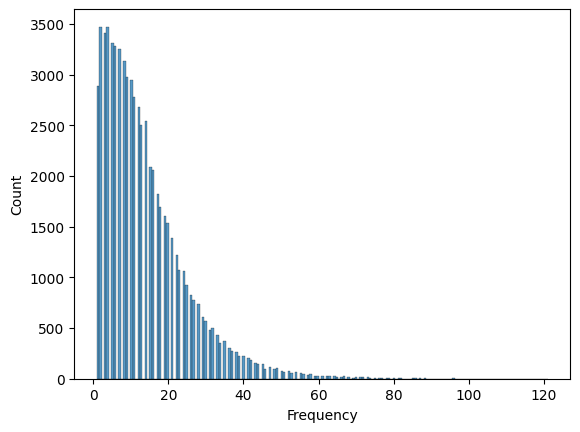

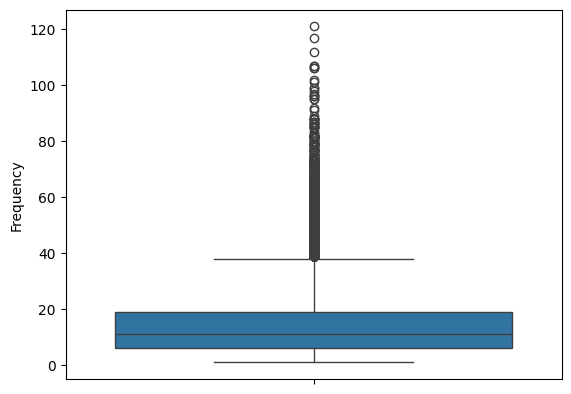

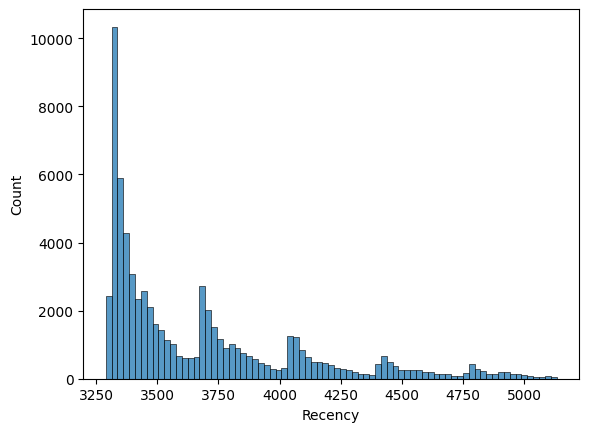

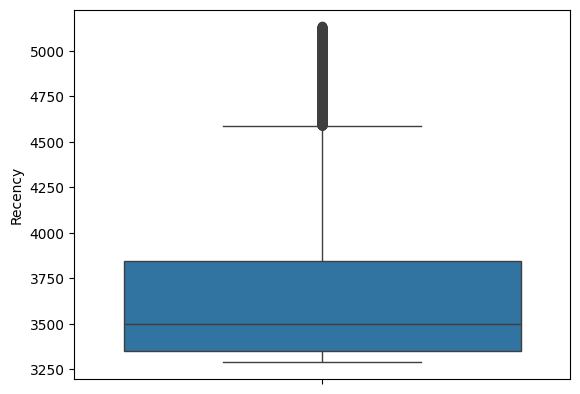

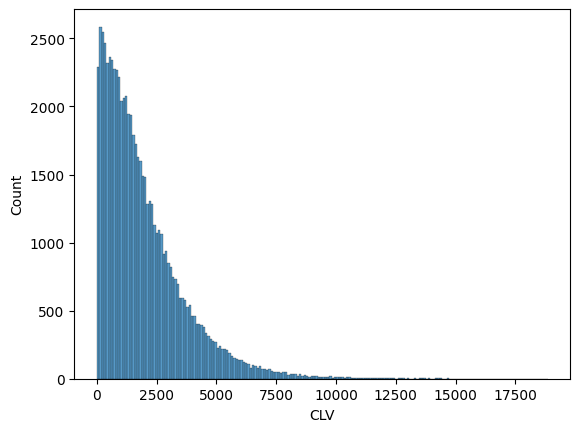

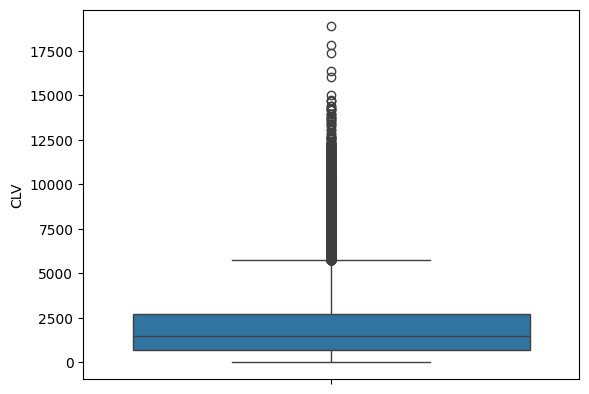

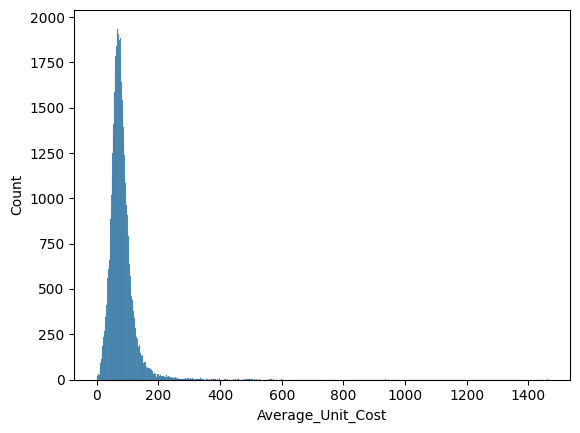

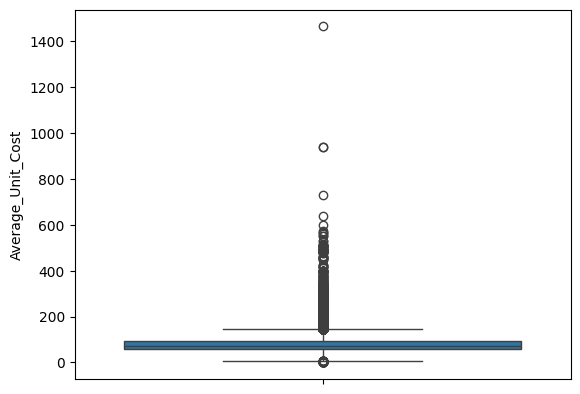

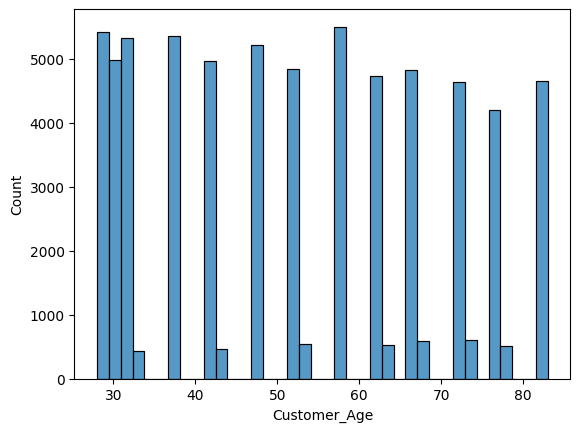

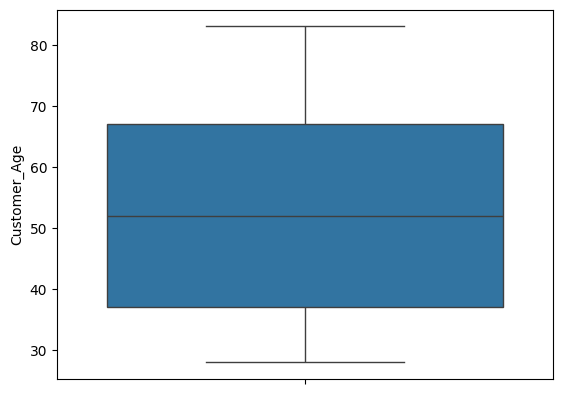

In [30]:
# Create histograms and boxplots for each feature
sns.histplot(customer_aggregated['Frequency'])
plt.show()
sns.boxplot(customer_aggregated['Frequency'])
plt.show()
sns.histplot(customer_aggregated['Recency'])
plt.show()
sns.boxplot(customer_aggregated['Recency'])
plt.show()
sns.histplot(customer_aggregated['CLV'])
plt.show()
sns.boxplot(customer_aggregated['CLV'])
plt.show()
sns.histplot(customer_aggregated['Average_Unit_Cost'])
plt.show()
sns.boxplot(customer_aggregated['Average_Unit_Cost'])
plt.show()
sns.histplot(customer_aggregated['Customer_Age'])
plt.show()
sns.boxplot(customer_aggregated['Customer_Age'])
plt.show()

Frequency and CLV show a distribution which is skewed to the right with many outliers in the higher values. Recency shows an interesting distribution, which is also skewed to the right, but has peaks which seems to repeat every year (365 days) and then gradually decrease until the next peak. The outlier are also in the higher values. Average Unit Cost looks normally distributed in the histogram. However, looking at the boxplot, it seems skewed to the right with many outliers in the higher values (which may not be clearly shown due to the high peak in the histogram). Customer age seems to be quite evenly distributed over all age groups. The boxplot does not have any ouliers.

# Scaling

In [31]:
from sklearn.preprocessing import RobustScaler

# Features used for scaling
features = ['Frequency', 'Recency', 'CLV', 'Average_Unit_Cost', 'Customer_Age']

# perform scaling
scaler = RobustScaler()
customer_scaled = pd.DataFrame(
    scaler.fit_transform(customer_aggregated[features]),
    columns=features,
    index=customer_aggregated.index
)

# View scaled dataset
customer_scaled.head()

,Frequency,Recency,CLV,Average_Unit_Cost,Customer_Age
Customer ID,,,,,
1,1.846154,-0.346154,1.402938,0.462893,0.666667
3,0.692308,-0.139676,0.657250,0.488084,-0.333333
4,-0.153846,1.862348,-0.354908,-1.037716,-0.333333
5,0.615385,-0.370445,0.652275,0.987619,-0.500000
6,0.307692,0.004049,0.053222,-0.598869,0.500000


RobustScaler was used to scale the features because several variables (such as CLV, Frequency and Recency) are heavily skewed and contain outliers. RobustScaler scales data using the median and interquartile range (IQR), which reduces the influence of extreme values compared to standardisation or normalisation. (Scikit-learn, 2023)

# K-means clustering

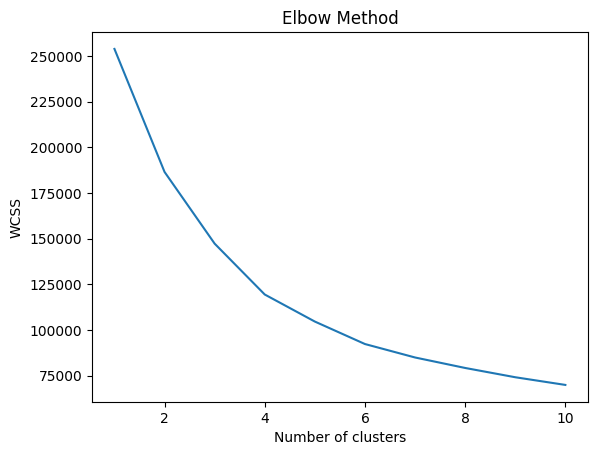

In [32]:
# Perform Kmeans with 1-10 clusters using a loop and use the elbow method
from sklearn.cluster import KMeans

# Define WCSS
wcss = []

# Loop through cluster sizes from 1-10
for n_clusters in range(1, 11):
    # Perform Kmeans
    kmeans = KMeans(n_clusters=n_clusters, init='k-means++', random_state=0, n_init=10)

    # Fit Kmeans to the scaled data
    kmeans.fit(customer_scaled)

    # Use the elbow method
    wcss.append(kmeans.inertia_)

# Create plot for elbow method
plt.plot(range(1, 11), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

The pipeline was repeated with 1-10 clusters. The elbow method shows that the decline in WCSS stabilises after 6 clusters. I will use the silhouette score to confirm. As it takes a long time to perform, I will use a sample of the dataset.

In [34]:
# Make a smaller dataframe (reproducible sample)
customer_sample = customer_scaled.sample(n=20000, random_state=42)

# View output
print(customer_sample.shape)
customer_sample.head()

(20000, 5)


,Frequency,Recency,CLV,Average_Unit_Cost,Customer_Age
Customer ID,,,,,
86887,-0.769231,0.878543,-0.631131,0.989050,1.000000
14639,0.076923,2.151822,-0.158463,-0.704215,-0.633333
58509,0.615385,-0.358300,0.671005,0.026623,0.333333
9745,-0.230769,-0.348178,-0.439656,-0.374150,0.833333
61006,1.230769,-0.309717,1.283565,0.138553,-0.666667


In [35]:
# Predict the Silhouette Score
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Perform Silhouette Method in range 2-10 clusters
for n_clusters in range(2, 11):
    kmeans = KMeans(n_clusters=n_clusters, random_state=10, n_init=10)

    # Fit KMeans to the scaled data
    cluster_labels = kmeans.fit_predict(customer_sample)

    # Calculate silhouette score
    silhouette_avg = silhouette_score(customer_sample, cluster_labels)

    # View output
    print(f"For n_clusters = {n_clusters}, the silhouette score is {silhouette_avg}")

For n_clusters = 2, the silhouette score is 0.27472564109297226
For n_clusters = 3, the silhouette score is 0.2924546558591861
For n_clusters = 4, the silhouette score is 0.2828336458035965
For n_clusters = 5, the silhouette score is 0.23956951040779803
For n_clusters = 6, the silhouette score is 0.2464813904739463
For n_clusters = 7, the silhouette score is 0.22606713227412115
For n_clusters = 8, the silhouette score is 0.22410705529561045
For n_clusters = 9, the silhouette score is 0.22399995303250717
For n_clusters = 10, the silhouette score is 0.21201850330752886


The number of clusters with the highest silhouette score are 2 clusters (0.27), 3 clusters (0.29) and 4 clusters (0.28). The silhouette score for 6 clusters (0.25).

Now, I will explore the optimal number of clusters using a dendogram.

# Hierarchical clustering and dendrogram

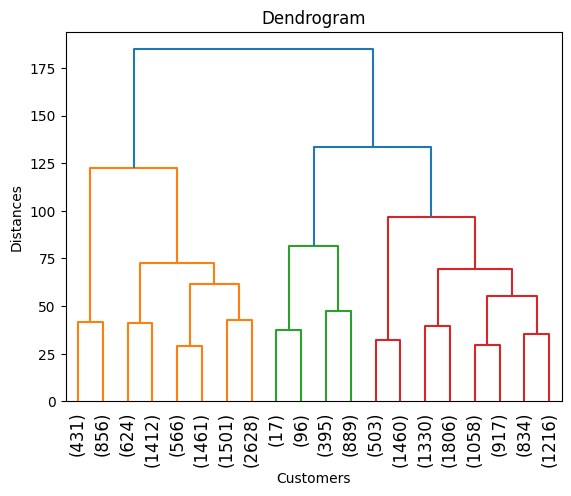

In [36]:
# Perform hierarchical clustering and make a dendrogram
# Import required libraries
from scipy.cluster.hierarchy import dendrogram, linkage

# Perform hierarchical clustering
Z = linkage(customer_sample, 'ward')

# Create a dendogram
dendrogram(Z, truncate_mode='lastp', p=20, leaf_rotation=90, leaf_font_size=12)
plt.title('Dendrogram')
plt.xlabel('Customers')
plt.ylabel('Distances')
plt.show()

There is no absolute right or wrong answer in the selection of clusters (University of Cambridge, 2023). The cutoff point for 2, 3 or 4 clusters are at very similar distances: respectively at 130, 125 and 120 distances. However, the cutoff point for 6 clusters is around 75, which makes 6 clusters less preferable based on the hierarchical clustering method.

Based on the combination of the three methods, I will choose 4 clusters. This is in the middle of the Elbow, slightly higher than 6 clusters. The silhouette score is 0.28 which is clearly higher than the score for 5 or 6 clusters. The dendrogram confirms that 2, 3, or 4 clusters is prefered over 5 or 6 clusters.

# K-means clustering with 4 clusters

In [38]:
# Perform k-means clustering with 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(customer_scaled)

# Make a new dataframe with Customer ID and Cluster number
customer_clusters = pd.DataFrame({
    'Customer ID': customer_scaled.index,
    'Cluster': kmeans.labels_
})

# View output
customer_clusters.head(20)

,Customer ID,Cluster
0,1,1
1,3,0
2,4,2
3,5,0
4,6,0
5,7,1
6,9,1
7,10,1
8,11,0
9,12,0


Kmeans clustering was performed with 4 clusters. A dataframe was created which assigns a cluster number to each customer ID (the first 20 rows are shown).

In [39]:
# Add cluster labels back to the aggregated dataframe (match by Customer ID index)
customer_aggregated = customer_aggregated.join(customer_clusters.set_index('Customer ID'))

# Check output
customer_aggregated.head()

,Frequency,Recency,CLV,Average_Unit_Cost,Customer_Age,Cluster
Customer ID,,,,,,
1,35,3326,4322.70,89.62,72,1
3,20,3428,2821.00,90.50,42,0
4,9,4417,782.67,37.20,42,2
5,19,3314,2810.98,107.95,37,0
6,15,3499,1604.58,52.53,67,0


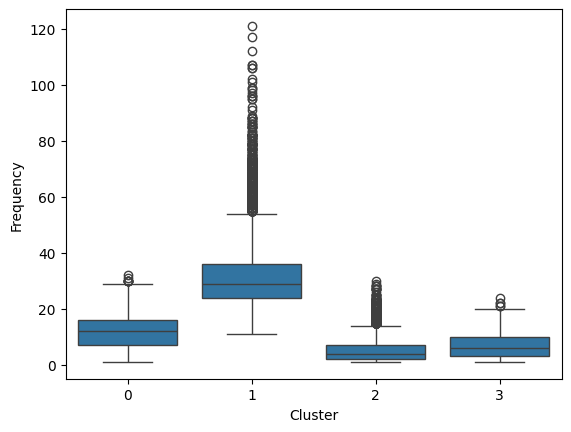

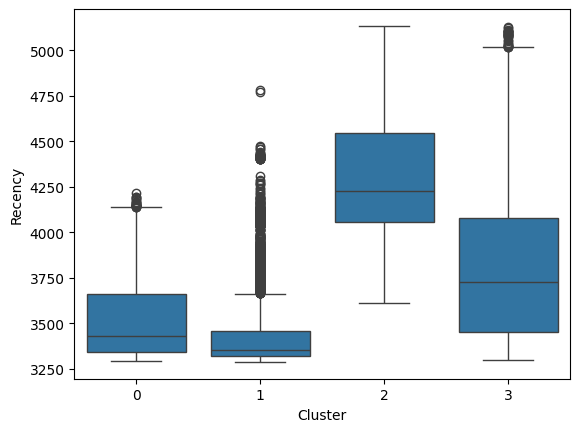

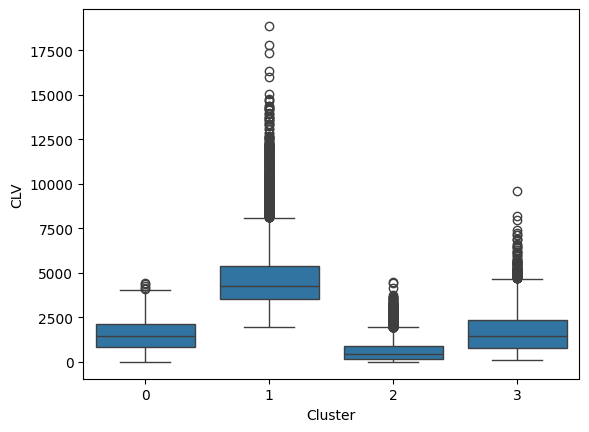

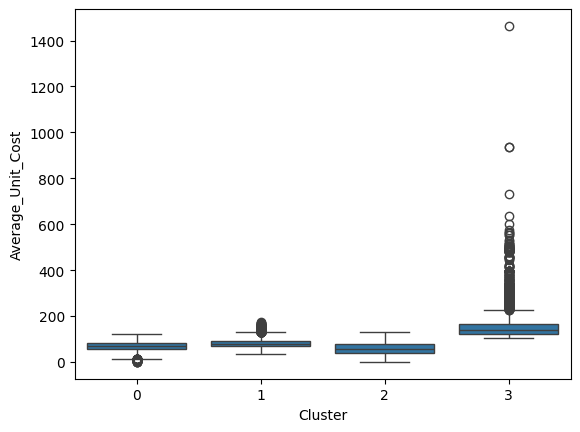

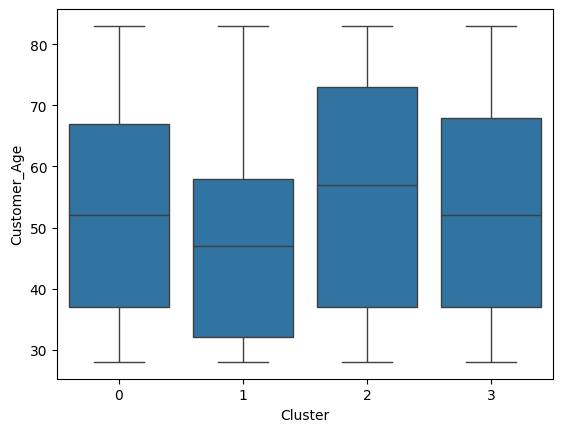

In [40]:
# Create boxplots to display the clusters with regard to frequency, recency, CLV, average unit cost, and customer age.
sns.boxplot(x='Cluster', y='Frequency', data=customer_aggregated)
plt.show()
sns.boxplot(x='Cluster', y='Recency', data=customer_aggregated)
plt.show()
sns.boxplot(x='Cluster', y='CLV', data=customer_aggregated)
plt.show()
sns.boxplot(x='Cluster', y='Average_Unit_Cost', data=customer_aggregated)
plt.show()
sns.boxplot(x='Cluster', y='Customer_Age', data=customer_aggregated)
plt.show()

From the boxplot we can observe the following for each cluster:
Cluster 3 has a higher average unit cost than the other clusters. Cluster 2 has a higher recency than the other clusters. Cluster 1 has a higher frequency and CLV than the other clusters. Cluster 0 scores low-average compared to the other clusters when it comes to average unit cost, recency, frequency and CLV and has an average age.

# Dimensionality reduction with PCA

In [66]:
# Perform dimensionality reduction with PCA
from sklearn.decomposition import PCA

# Perform PCA
pca = PCA(n_components=2)

# Fit the PCA model to the data
customer_pca = pca.fit_transform(customer_scaled)

# Convert back to a Pandas DataFrame
customer_pca = pd.DataFrame(customer_pca, columns=['PC1', 'PC2'])

# View output
print(customer_pca.shape)
customer_pca.head()

(68300, 2)


,PC1,PC2
0,2.042727,-0.148744
1,0.863590,0.136764
2,-1.413270,-0.835050
3,1.021455,0.595577
4,-0.115573,-0.794282


PCA was performed and the dataframe now has 2 columns: PC1 and PC2.

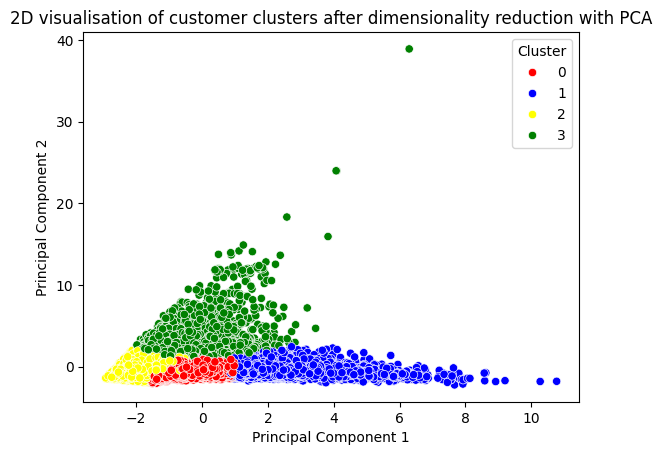

In [67]:
# Create 2D visualisation with the two principal components and the clusters in different colours
# Add 'Cluster' feature to the dataframe for PCA
customer_pca['Cluster'] = customer_clusters['Cluster']

# Create visualisation
sns.scatterplot(
    x='PC1', y='PC2',
    hue='Cluster',
    data=customer_pca,
    palette=["Red", "Blue", "Yellow", "Green"]
)

plt.title('2D visualisation of customer clusters after dimensionality reduction with PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.legend(title='Cluster')
plt.show()

# Dimensionality reduction with t-SNE

t-SNE is computationally heavy. Therefore I will use a sample of the dataset.

In [68]:
# Create sample
customer_sample = customer_scaled.sample(n=10000, random_state=42)

# View sample
print(customer_sample.shape)
customer_sample.head()

(10000, 5)


,Frequency,Recency,CLV,Average_Unit_Cost,Customer_Age
Customer ID,,,,,
86887,-0.769231,0.878543,-0.631131,0.989050,1.000000
14639,0.076923,2.151822,-0.158463,-0.704215,-0.633333
58509,0.615385,-0.358300,0.671005,0.026623,0.333333
9745,-0.230769,-0.348178,-0.439656,-0.374150,0.833333
61006,1.230769,-0.309717,1.283565,0.138553,-0.666667


In [69]:
# Perform dimensionality reduction with t-SNE on the sample
from sklearn.manifold import TSNE

# Perform t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_result = tsne.fit_transform(customer_sample)

# Create dataframe of t-SNE
customer_tsne = pd.DataFrame(
    tsne_result,
    columns=['TSNE1', 'TSNE2'],
    index=customer_sample.index
)

# View output
print(customer_tsne.shape)
customer_tsne.head()

(10000, 2)


,TSNE1,TSNE2
Customer ID,,
86887,-18.032246,53.521019
14639,-54.793835,34.023079
58509,43.979309,-33.210407
9745,-29.192499,-48.760090
61006,71.864265,-10.072144


In [70]:
# Add clusters to the t-SNE dataframe
# First ensure Customer ID is a column
customer_tsne = customer_tsne.reset_index().rename(columns={'index': 'Customer ID'})

# then merge
customer_tsne = customer_tsne.merge(customer_clusters, on='Customer ID', how='left')

# View
customer_tsne.head()

,Customer ID,TSNE1,TSNE2,Cluster
0,86887,-18.032246,53.521019,2
1,14639,-54.793835,34.023079,2
2,58509,43.979309,-33.210407,0
3,9745,-29.192499,-48.760090,0
4,61006,71.864265,-10.072144,1


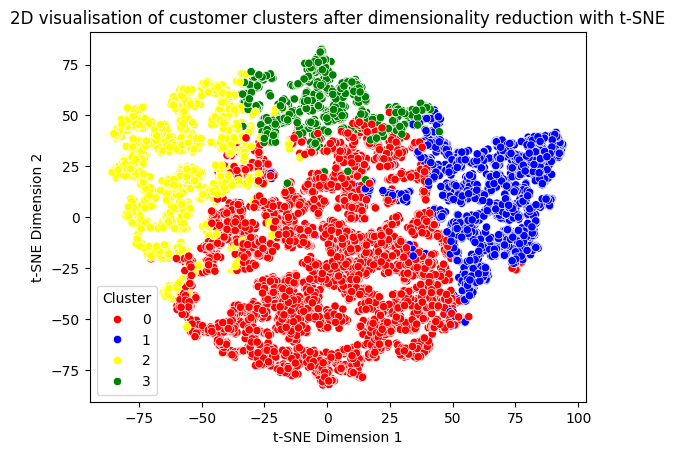

In [71]:
# Create visualisation
sns.scatterplot(
    x='TSNE1', y='TSNE2',
    hue='Cluster',
    data=customer_tsne,
    palette=["Red", "Blue", "Yellow", "Green"]
)

plt.title('2D visualisation of customer clusters after dimensionality reduction with t-SNE')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')

plt.legend(title='Cluster')
plt.show()

t-SNE was used for visualisation of the complete dataset with 4 customer clusters.

In [72]:
# Perform t-SNE with perplexity of 10
tsne = TSNE(n_components=2, perplexity=10, random_state=42)
tsne_result = tsne.fit_transform(customer_sample)

# Create dataframe of t-SNE
customer_tsne = pd.DataFrame(
    tsne_result,
    columns=['TSNE1', 'TSNE2'],
    index=customer_sample.index
)

# Add clusters to the t-SNE dataframe
customer_tsne = customer_tsne.reset_index().rename(columns={'index': 'Customer ID'})
customer_tsne = customer_tsne.merge(customer_clusters, on='Customer ID', how='left')

# View
customer_tsne.head()

,Customer ID,TSNE1,TSNE2,Cluster
0,86887,-22.370409,55.398434,2
1,14639,-69.670403,38.157558,2
2,58509,43.114738,-43.953766,0
3,9745,-37.637051,-58.065094,0
4,61006,78.863571,-16.364820,1


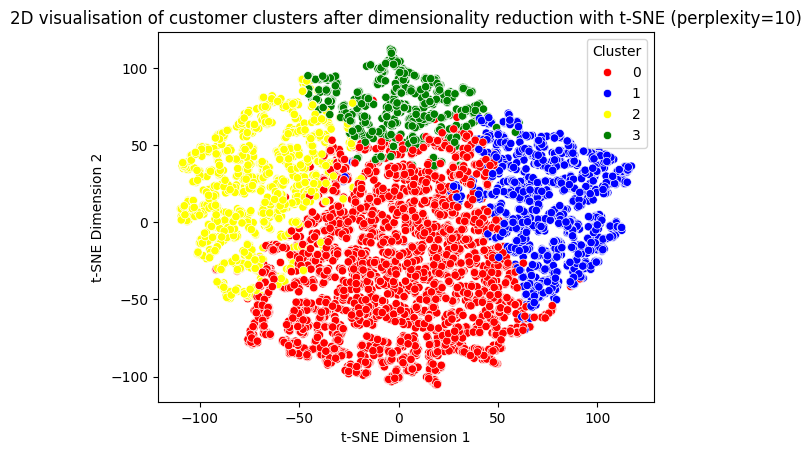

In [73]:
# Create visualisation
sns.scatterplot(
    x='TSNE1', y='TSNE2',
    hue='Cluster',
    data=customer_tsne,
    palette=["Red", "Blue", "Yellow", "Green"]
)

plt.title('2D visualisation of customer clusters after dimensionality reduction with t-SNE (perplexity=10)')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')

plt.legend(title='Cluster')
plt.show()

In [74]:
# Perform t-SNE with perplexity of 50
tsne = TSNE(n_components=2, perplexity=50, random_state=42)
tsne_result = tsne.fit_transform(customer_sample)

# Create dataframe of t-SNE
customer_tsne = pd.DataFrame(
    tsne_result,
    columns=['TSNE1', 'TSNE2'],
    index=customer_sample.index
)

# Add clusters to the t-SNE dataframe
customer_tsne = customer_tsne.reset_index().rename(columns={'index': 'Customer ID'})
customer_tsne = customer_tsne.merge(customer_clusters, on='Customer ID', how='left')

# View
customer_tsne.head()

,Customer ID,TSNE1,TSNE2,Cluster
0,86887,-16.077215,49.555775,2
1,14639,-46.101482,30.053730,2
2,58509,35.879856,-28.273031,0
3,9745,-24.474161,-41.920551,0
4,61006,58.027138,-7.120074,1


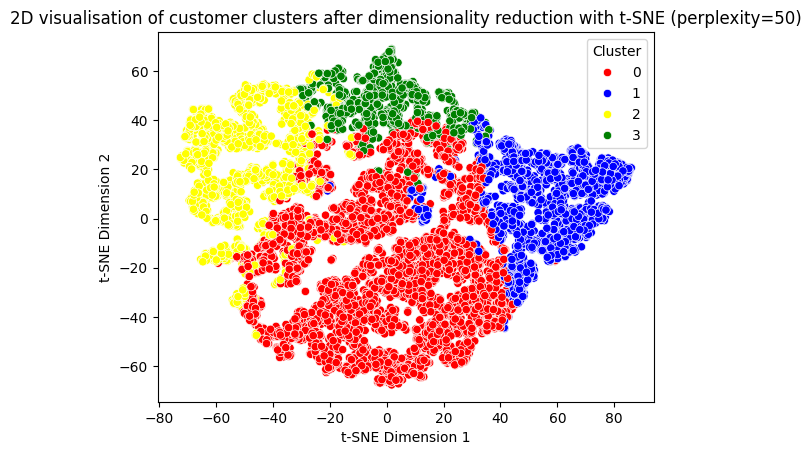

In [75]:
# Create visualisation
sns.scatterplot(
    x='TSNE1', y='TSNE2',
    hue='Cluster',
    data=customer_tsne,
    palette=["Red", "Blue", "Yellow", "Green"]
)

plt.title('2D visualisation of customer clusters after dimensionality reduction with t-SNE (perplexity=50)')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')

plt.legend(title='Cluster')
plt.show()

# References

Cardona, A., 2023. Mini-Project 6.3. Presentation at University of Cambridge, Institute of Continuing Education, Monday 24 March. Available at: https://studentcommunity.fourthrev.com/c/content-discussions-176e5b/ [Accessed 5 April 2025]. Password protected.

Gupta, R., 2023. Mastering GroupBy Aggregation in Pandas: Using Different Aggregated Functions on Different Columns and Renaming Them. Geek Culture. Available at: https://medium.com/geekculture/mastering-groupby-aggregation-in-pandas-using-different-aggregated-functions-on-different-columns-9dca54b75961 [Accessed 5 April 2025].

SAS, 2024. CUSTOMERS_CLEAN [Data set]. SAS. Last revised on 15 December 2021. [Accessed 20 February 2024].

Scikit-learn, 2023. RobustScaler. Available at: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.RobustScaler.html
 [Accessed 21 January 2026].

University of Cambridge, Institute for Continuing Education, 2023. CAM_DS_101 Applying statistics and core data science techniques in business: 6.1.4 Choosing the appropriate number of clusters. Available at: https://fourthrev.instructure.com/courses/840/modules [Accessed 5 April 2025]. Password protected.

University of Cambridge, Institute for Continuing Education, 2023. CAM_DS_101 Applying statistics and core data science techniques in business: 6.2.2 Similarity measures Available at: https://fourthrev.instructure.com/courses/840/modules [Accessed 5 April 2025]. Password protected.